In [53]:
# let's create a simple dataset
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

X, y = make_blobs(
    n_samples=200,
    centers=2,
    n_features=2,
    random_state=42
)


In [54]:
print(X.shape)
print(y.shape)

(200, 2)
(200,)


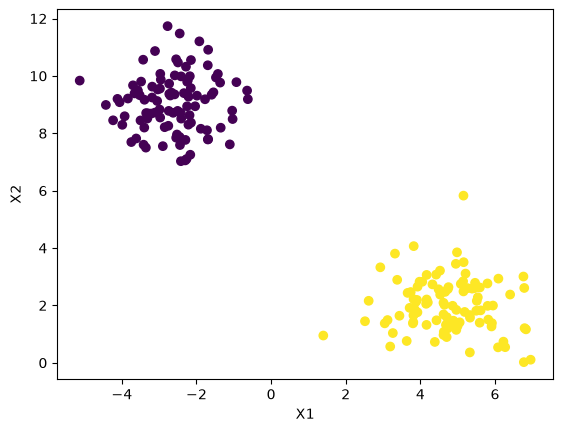

In [55]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

### Sigmoid function

$$
Z = XW + B
$$


In [56]:
def sigmoid(z):
    return (1/(1+np.exp(-z)))

$$
L
=
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
Y^{(i)}\log(\hat{Y}^{(i)})
+
(1-Y^{(i)})
\log(1-\hat{Y}^{(i)})
\right]
$$

In [57]:
def log_loss(y,y_hat):

    loss = -1* np.mean(
        y * np.log(y_hat) +
        (1-y) * np.log(1-y_hat)
    )
    return loss

In this we find the z and use sigmoid to find y_hat that should be in between 0,1

In [58]:
def forward_propagation(X,W,b):
    
    z = X@W + b 
    
    y_hat = sigmoid(z) 
    
    return z , y_hat

The simplified gradient for the weights is:

$$
dW
=
\frac{1}{m}X^T(\hat{Y}-Y)
$$

For the bias:

$$
dB
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
\hat{Y}^{(i)}-Y^{(i)}
\right)
$$

In [59]:
def backward_propagation(X,y,y_hat):
    m = len(y)
    dw = (X.T @ (y_hat - y))/m
    db = np.mean(y_hat-y)
    return dw,db


Gradient descent updates the weights:

$$
W = W - \alpha dW
$$

For individual weights:

$$
W_1
=
W_1
-
\alpha
\frac{\partial L}{\partial W_1}
$$

In [60]:
def update_parameters(W, b, dW, db, learning_rate):
    W = W - learning_rate * dW
    b = b - learning_rate * db

    return W, b

In [61]:
def train(X, y, learning_rate=0.1, epochs=1000):

    n_features = X.shape[1]

    W = np.zeros(n_features)
    b = 0

    losses = []

    for epoch in range(epochs):

        # Forward propagation
        Z, y_hat = forward_propagation(X, W, b)

        # Calculate loss
        loss = log_loss(y, y_hat)
        losses.append(loss)

        # Backward propagation
        dW, db = backward_propagation(X, y, y_hat)

        # Update weights
        W, b = update_parameters(
            W,
            b,
            dW,
            db,
            learning_rate
        )

    return W, b, losses

In [62]:
W, b, losses = train(
    X,
    y
)

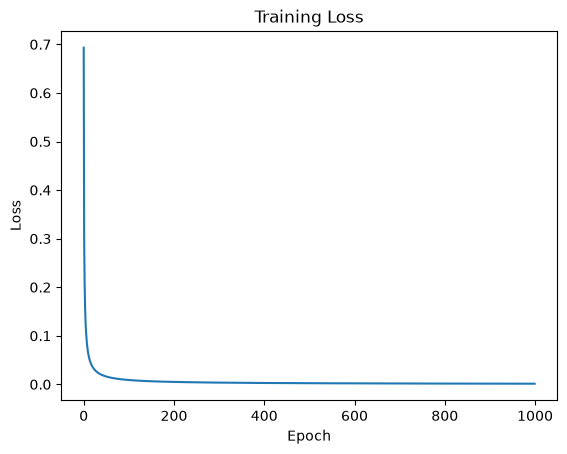

In [63]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [64]:
W

array([ 1.84917596, -0.4582387 ])